# CatBench Tutorial

A complete walkthrough of CatBench — from dataset download to benchmarking
report — in a single notebook.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JinukMoon/catbench/blob/main/tutorials/catbench_tutorial.ipynb)

**What you will do (~10 minutes on a GPU):**
1. Download the main CatBench benchmark dataset (MamunHighT2019, 195 MB) from Zenodo
2. Set up **MACE-MP-0** as the representative MLIP
3. Run benchmark calculations on a 20-reaction subset
4. Generate parity plots, MAE tables, and an Excel anomaly report

**Note:** A GPU is strongly recommended. On Colab: *Runtime → Change runtime type → GPU*. CPU-only runs will take hours instead of minutes. The full MamunHighT2019 dataset has 45,130 reactions; this tutorial uses a 20-reaction subset so the entire notebook completes in about 10 minutes.

## 1. Setup

Install CatBench and MACE (the representative MLIP used in this tutorial), then import the functions we will need.

In [1]:
!pip install --quiet catbench mace-torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.3/264.3 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.3 MB/s eta 0:00:00


In [2]:
import json

import torch
assert torch.cuda.is_available(), (
    "CUDA is not available. On Colab: Runtime > Change runtime type > T4 GPU, "
    "then Runtime > Restart session."
)
print(f"torch {torch.__version__} | device: {torch.cuda.get_device_name(0)}")

from catbench.adsorption import (
    zenodo_download,
    list_zenodo_benchmarks,
    AdsorptionCalculation,
    AdsorptionAnalysis,
)

torch 2.10.0+cu128 | device: Tesla T4


## 2. Download the benchmark dataset

CatBench supports three data sources. This tutorial uses **Option A (Zenodo)** — pre-formatted JSON files published with the CatBench paper, ready to use without any preprocessing.

- **Option A** — Zenodo (5 main datasets, fastest, used here)
- **Option B** — CatHub (for benchmarks not on Zenodo)
- **Option C** — Your own VASP data (see [README Option C](../README.md#option-c-user-vasp-data); requires `rate=None`)

See `list_zenodo_benchmarks()` for the 5 available datasets.

In [3]:
# === Option A: Zenodo download (default in this tutorial) ===
print("Available Zenodo benchmarks:", list_zenodo_benchmarks())

zenodo_download("MamunHighT2019")   # 195 MB, MD5-verified

# === Option B: CatHub download (for benchmarks not on Zenodo) ===
# To use this path instead, delete the leading "#" on the two lines below:
# from catbench.adsorption import cathub_preprocessing
# cathub_preprocessing("MamunHighT2019")

# === Option C: User VASP data ===
# See the next markdown section "2b. Using your own VASP data" for the
# folder structure, coeff_setting examples, and the rate=None rule.


# --- Build a 20-reaction subset so this tutorial finishes quickly ---
# For a real benchmark, skip this block and use benchmark="MamunHighT2019" below.
with open("raw_data/MamunHighT2019_adsorption.json") as f:
    full_data = json.load(f)

tutorial_subset = dict(list(full_data.items())[:20])

with open("raw_data/MamunTutorial_adsorption.json", "w") as f:
    json.dump(tutorial_subset, f)

print(f"Full dataset:    {len(full_data):>6} reactions")
print(f"Tutorial subset: {len(tutorial_subset):>6} reactions")

Available Zenodo benchmarks: ['BM_dataset', 'ComerGeneralized2024', 'FG_dataset', 'KHLOHC_origin', 'MamunHighT2019']
  URL:    https://zenodo.org/api/records/17157086/files/MamunHighT2019_adsorption.json/content
  Target: /content/raw_data/MamunHighT2019_adsorption.json
    190.4 / 195.4 MB ( 97.5%)
MD5 verified: 8a208683009546b4d0f9821113ab1cc6
Saved: /content/raw_data/MamunHighT2019_adsorption.json
Full dataset:     45130 reactions
Tutorial subset:     20 reactions


### 2b. (Optional) Using your own VASP data

If you want to benchmark your MLIP against your own DFT calculations instead of the Zenodo dataset, here is how to prepare the data. **Skip this section if you are following the Zenodo path above.**

#### Required folder structure

The folder name is arbitrary, but the bolded names below (`gas`, `slab`, and the `<X>gas` pattern) are hard-coded and must be exact.

```
my_vasp_folder/
├── gas/                          # reserved name
│   ├── H2gas/                    # every gas-reference folder must end with "gas"
│   │   ├── CONTCAR
│   │   └── OSZICAR
│   └── H2Ogas/
│       ├── CONTCAR
│       └── OSZICAR
├── surface_A/                    # any name for a surface variant
│   ├── slab/                     # reserved name (clean-surface reference)
│   │   ├── CONTCAR
│   │   └── OSZICAR
│   ├── H/                        # adsorbate folder; name matches coeff_setting key
│   │   ├── site_0/               # adsorption-site variants (any name)
│   │   │   ├── CONTCAR
│   │   │   └── OSZICAR
│   │   ├── site_1/
│   │   └── ...
│   └── OH/
│       └── ...
├── surface_B/
│   └── ...
```

**Warning:** `vasp_preprocessing` deletes every file except `CONTCAR` and `OSZICAR` to save disk space. Always run it on a copy of your original VASP output, never on the primary data.

#### coeff_setting examples

`coeff_setting` declares the reaction stoichiometry for each adsorbate. The keys `"slab"` and `"adslab"` are required on every entry; all other keys are gas-phase references and must end with `"gas"`. CatBench validates these rules at call time and raises a clear error on misnamed entries, before any files are deleted.

**Example 1 — two simple adsorbates with H2 / H2O gas references:**

```python
from catbench.adsorption import vasp_preprocessing

coeff_setting = {
    "H": {                      # E_ads(H*) = E(adslab) - E(slab) - 0.5 * E(H2gas)
        "slab":   -1,
        "adslab": +1,
        "H2gas":  -0.5,
    },
    "OH": {                     # E_ads(OH*) = E(adslab) - E(slab) + 0.5 * E(H2gas) - E(H2Ogas)
        "slab":   -1,
        "adslab": +1,
        "H2gas":  +0.5,
        "H2Ogas": -1,
    },
}

vasp_preprocessing("my_vasp_data", coeff_setting)
# Creates raw_data/my_vasp_data_adsorption.json
```

**Example 2 — larger molecules, each with its own gas-phase reference:**

```python
coeff_setting = {
    "H":    {"slab": -1, "adslab": +1, "H2gas":   -0.5},
    "Mol1": {"slab": -1, "adslab": +1, "Mol1gas": -1.0},   # e.g. a cyclic alkane
    "Mol2": {"slab": -1, "adslab": +1, "Mol2gas": -1.0},   # e.g. an aromatic
}

vasp_preprocessing("my_vasp_data", coeff_setting)
```

Even large / custom-named molecules follow the `<name>gas` rule — `"Mol1gas"` works; `"Mol1"` or `"Molecule1"` would raise a `ValueError`.

#### Calculation — the `rate=None` rule

When running `AdsorptionCalculation` on user VASP data, pass **`rate=None`**. Without it, CatBench ignores your VASP Selective Dynamics (T/F) constraints and instead fixes the bottom 50% of atoms by z-coordinate, producing energies inconsistent with your DFT references.

```python
calc_job = AdsorptionCalculation(
    calculators,
    mlip_name="MACE-MP-0",
    benchmark="my_vasp_data",
    rate=None,     # REQUIRED: preserve your VASP Selective Dynamics constraints
)
```

This is the single most common source of "why don't my MLIP and DFT results match?" confusion.

## 3. Set up the MLIP calculator

We use **MACE-MP-0** (the *small* foundation model) as a representative MLIP. Any ASE-compatible calculator can be plugged in — see the commented alternatives below.

In [4]:
from mace.calculators import mace_mp

calc = mace_mp(model="small", device="cuda")

# --- Optional: add Grimme's D3 dispersion correction ---
# To enable D3, delete the leading "#" on the three lines below:
# from catbench.dispersion import DispersionCorrection
# d3 = DispersionCorrection()            # Becke-Johnson damping + PBE parameters by default
# calc = d3.apply(calc)                  # wraps MACE in a SumCalculator with D3

# --- Swap in a different MLIP (pick one block; delete the leading "#") ---
# SevenNet-Omni:  from sevenn.calculator import SevenNetCalculator
#                 calc = SevenNetCalculator("7net-omni", modal="mpa", enable_cueq=True)
# CHGNet:         from chgnet.model import CHGNetCalculator
#                 calc = CHGNetCalculator()
# UMA:            from fairchem.core import FAIRChemCalculator, pretrained_mlip
#                 predictor = pretrained_mlip.get_predict_unit("uma-s-1", device="cuda")
#                 calc = FAIRChemCalculator(predictor, task_name="oc20")

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Cached MACE model to /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


## 4. Run the benchmark calculation

`AdsorptionCalculation` takes a **list** of calculators. Using the same MLIP multiple times provides per-seed reproducibility statistics that the analysis step uses for anomaly detection.

In [5]:
num_seeds = 3                      # number of reproducibility seeds
calculators = [calc] * num_seeds

calc_job = AdsorptionCalculation(
    calculators,
    mlip_name="MACE-MP-0",         # free-form label — used as the folder name under result/
                                   # and as the display name in parity plots and the Excel report
    benchmark="MamunTutorial",     # use "MamunHighT2019" to run the full 45,130-reaction benchmark
    # --- Commonly tuned options (delete the leading "#" to activate) ---
    # rate=None,                   # REQUIRED if you switched to Option C (user VASP data)
    # save_files=False,            # skip writing trajectory + log files to save disk space
    # f_crit_relax=0.05,           # force convergence criterion (eV/A), default 0.05
    # n_crit_relax=999,            # max optimization steps per structure, default 999
    # optimizer="LBFGS",           # ASE optimizer: LBFGS / BFGS / FIRE / ...
    # See the README "Configuration Options" section for the full list.
)

calc_job.run()
# Results land in ./result/MACE-MP-0/

Starting MACE-MP-0 Benchmarking in basic mode
Starting calculations...
[1/20] Sc3V9_0.5N2(g) + * -> N*
N2gas single point calculating
N2gas_0th calculating
N2gas_1th calculating
N2gas_2th calculating
[2/20] Hg6Ta6_H2O(g) - H2(g) + * -> O*
H2Ogas single point calculating
H2gas single point calculating
H2Ogas_0th calculating
H2gas_0th calculating
H2Ogas_1th calculating
H2gas_1th calculating
H2Ogas_2th calculating
H2gas_2th calculating
[3/20] Cu6Fe6_H2S(g) - 0.5H2(g) + * -> SH*
H2Sgas single point calculating
H2Sgas_0th calculating
H2Sgas_1th calculating
H2Sgas_2th calculating
[4/20] Ag6Cu6_H2O(g) - H2(g) + * -> O*
[5/20] Pt9Ti3_0.5H2(g) + * -> H*
[6/20] Ag6Pd6_CH4(g) - 2.0H2(g) + * -> C*
CH4gas single point calculating
CH4gas_0th calculating
CH4gas_1th calculating
CH4gas_2th calculating
[7/20] W6Zr6_H2S(g) - H2(g) + * -> S*
[8/20] Ag6V6_0.5H2(g) + * -> H*
[9/20] Y6Zr6_0.5N2(g) + * -> N*
[10/20] Y6Zr6_H2O(g) - H2(g) + * -> O*
[11/20] Y6Zr6_H2S(g) - H2(g) + * -> S*
[12/20] Ga6Re6_CH4(g) - 

'/content/result/MACE-MP-0'

## 5. Generate the analysis report

`AdsorptionAnalysis` auto-detects every MLIP under `./result/`, performs anomaly detection (displacement, energy, reproducibility, bond-length-change), and writes parity plots + an Excel report.

In [6]:
analysis = AdsorptionAnalysis(
    # --- Commonly tuned options (delete the leading "#" to activate) ---
    # mlip_list=["MACE-MP-0", "SevenNet-Omni"],   # analyze only specific MLIPs (default: all found)
    # target_adsorbates=["H", "OH"],              # plot only specific adsorbates
    # disp_thrs=0.5,                              # displacement anomaly threshold (A)
    # energy_thrs=2.0,                            # energy anomaly threshold (eV)
    # reproduction_thrs=0.2,                      # reproducibility threshold across seeds (eV)
    # font_setting=["~/fonts/Helvetica.ttf", "sans-serif"],   # custom font
    # See the README "Configuration Options" section for the full list.
)
analysis.analysis()
# Outputs:
#   ./plot/MACE-MP-0/ — mono + multi (per-adsorbate) parity plots
#   ./{cwd_name}_Benchmarking_Analysis.xlsx — MAE, RMSE, anomaly breakdown, timings


Analysis Configuration:
  Bond length threshold: 0.20
  Displacement threshold: 0.50 Å
  Energy threshold: 2.0 eV

Starting analysis...
Processing MLIP results...
Processing MACE-MP-0
  Generating plots for MACE-MP-0...
  Calculating ADwT metric for MACE-MP-0...
  ADwT: 69.4%
  Calculating AMDwT metric for MACE-MP-0...
  AMDwT: 79.7%
Excel file 'content_Benchmarking_Analysis.xlsx' created successfully.


All reactions combined (mono plot):


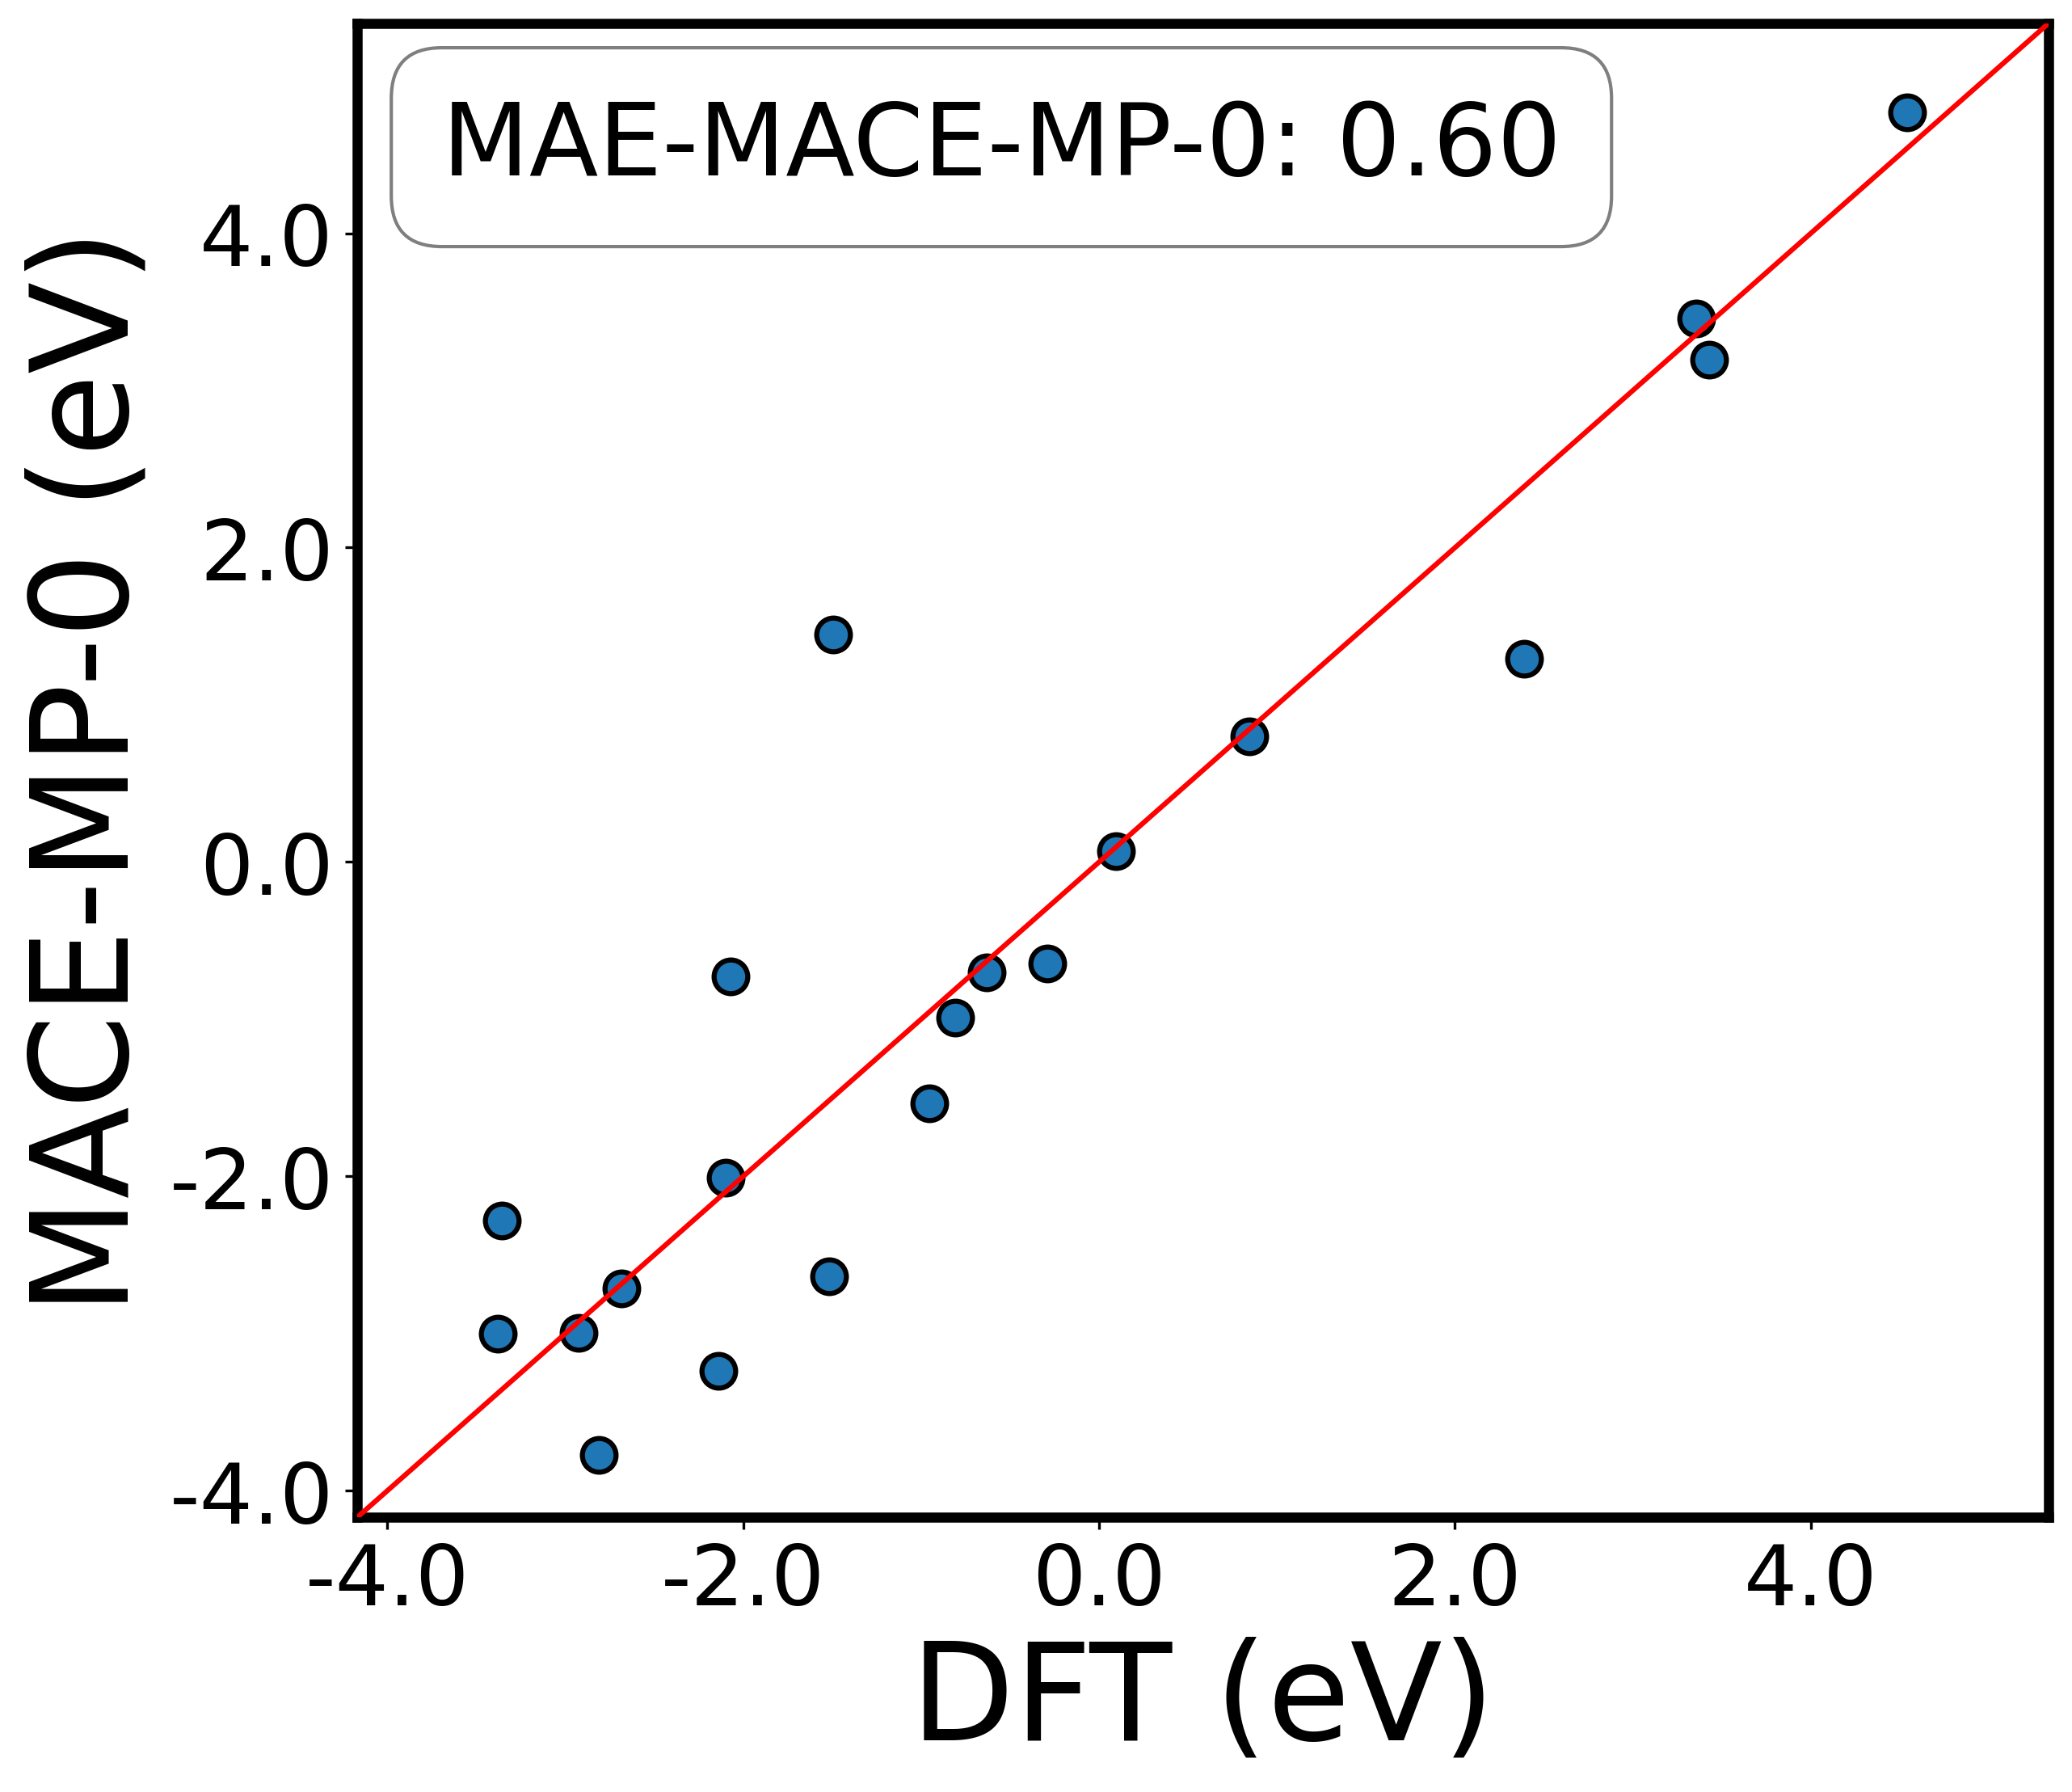

Colored by adsorbate (multi plot):


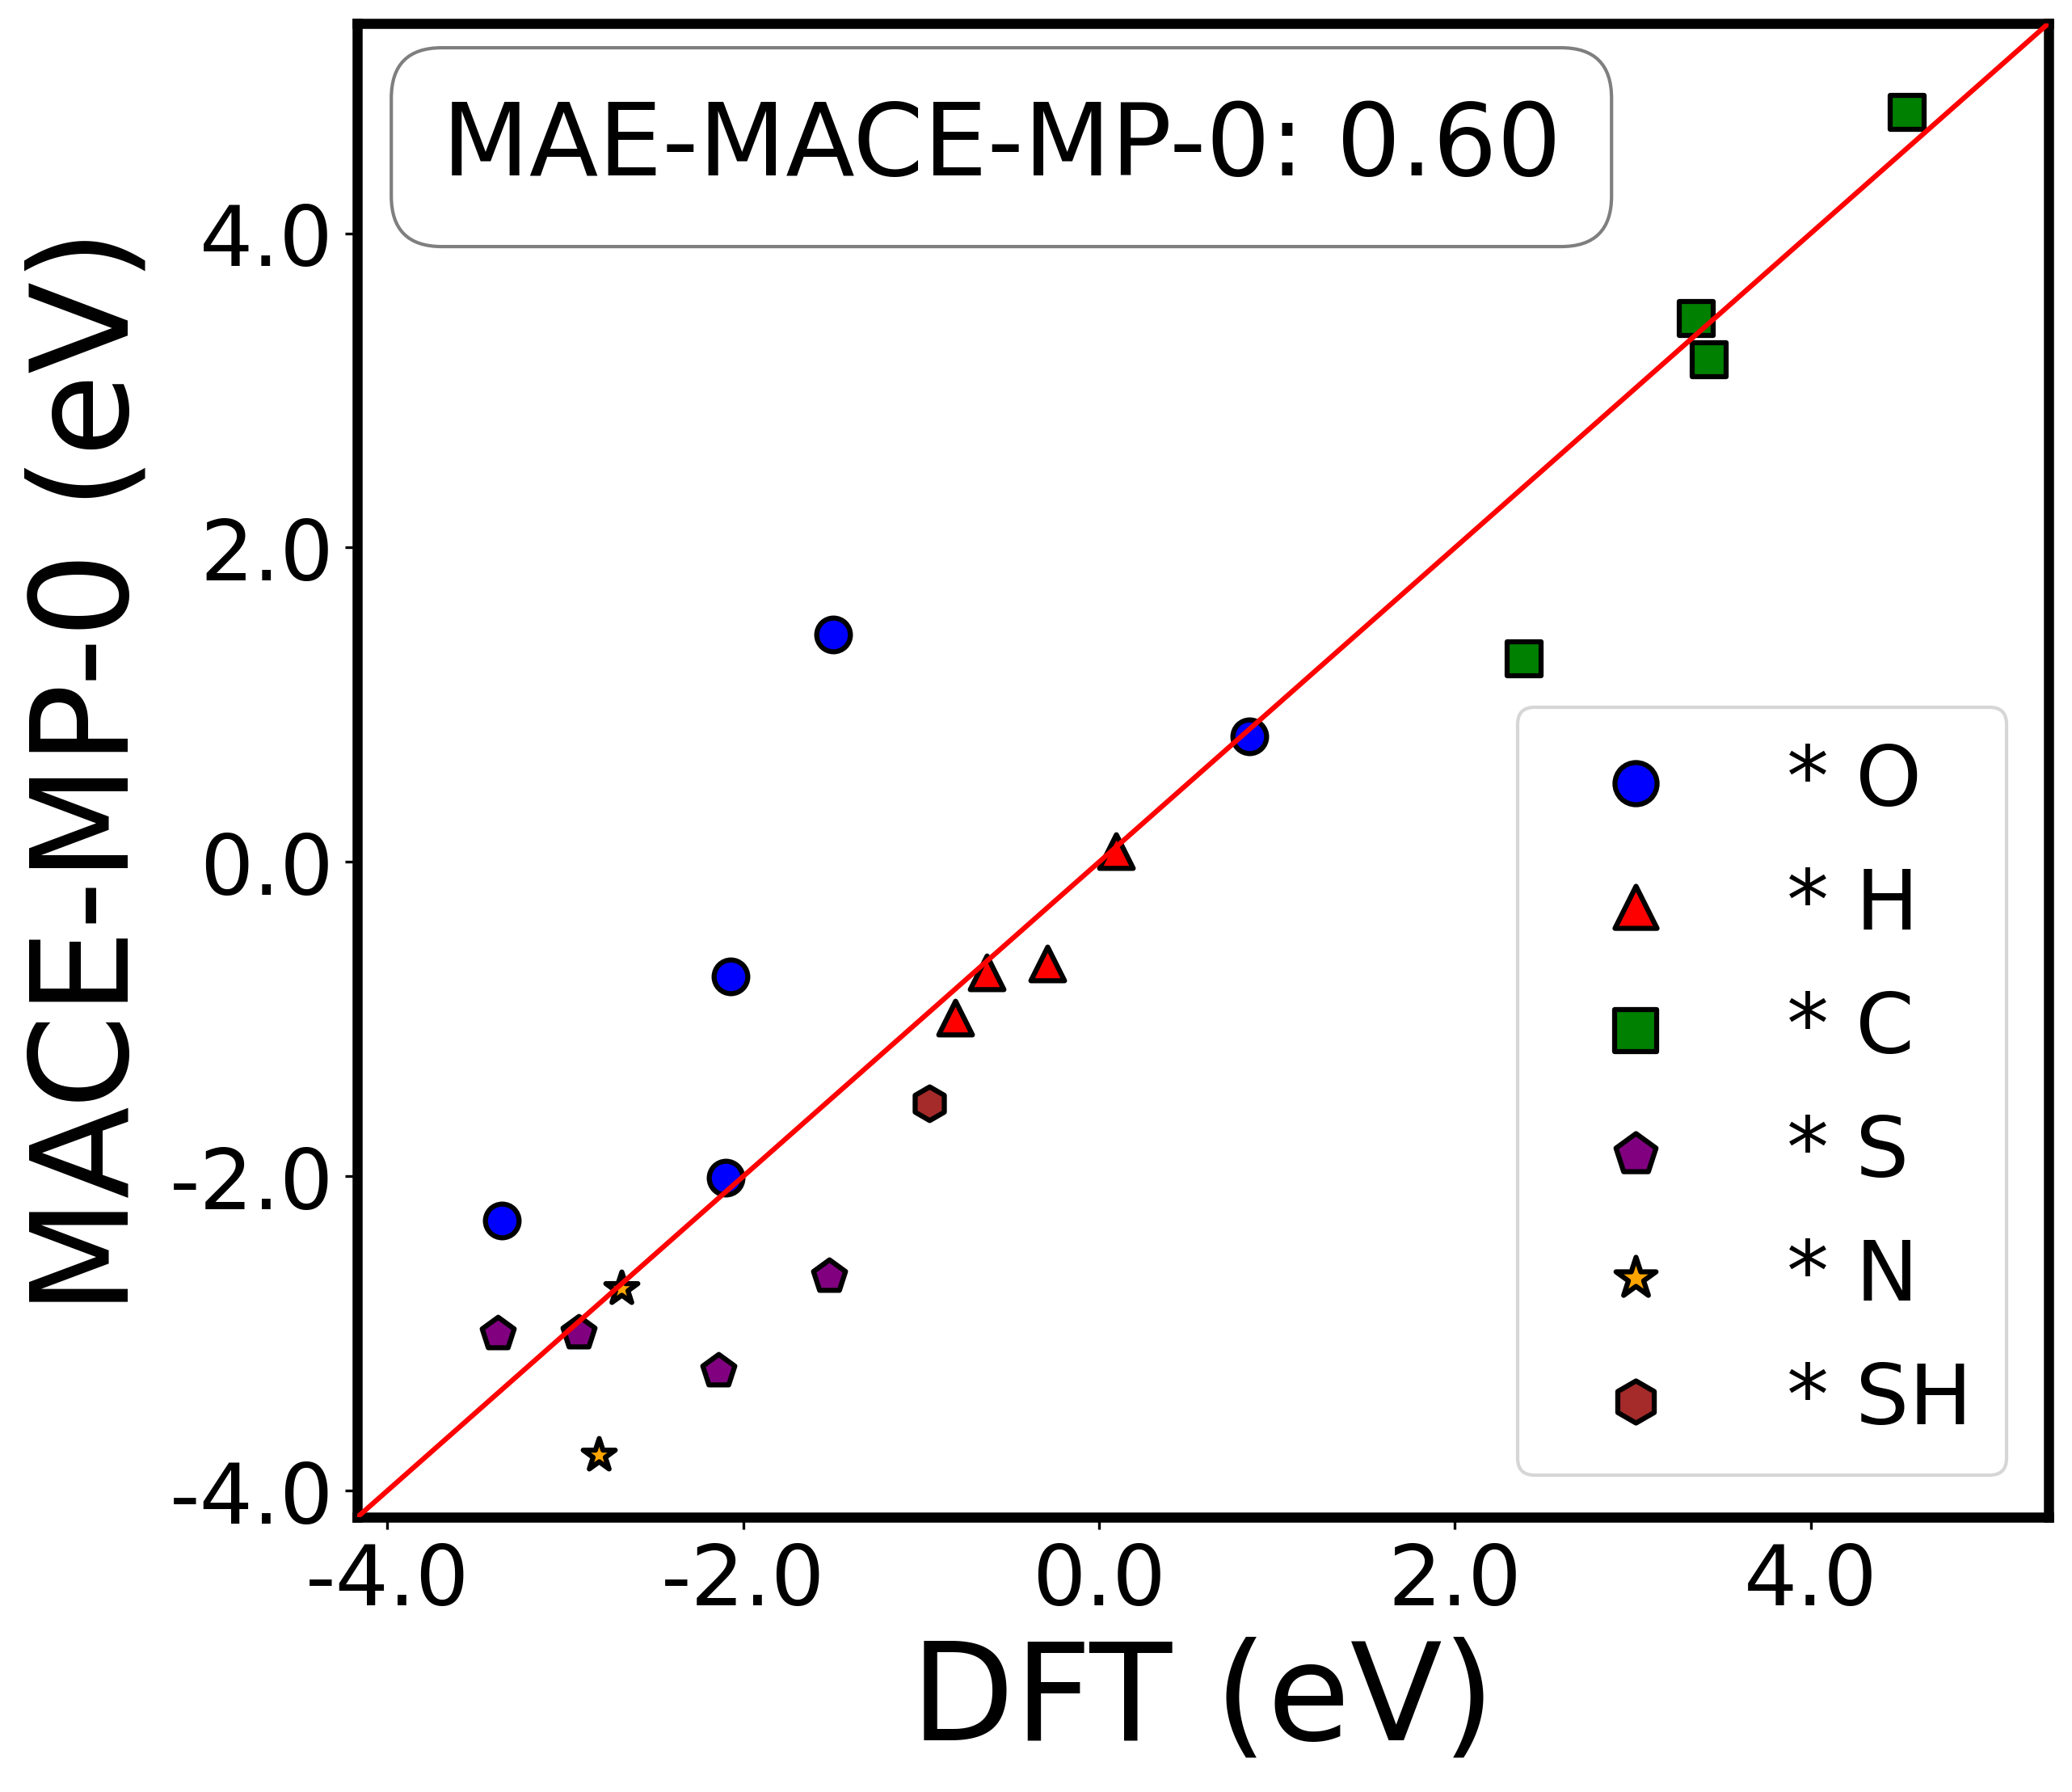

In [7]:
from IPython.display import Image, display

print("All reactions combined (mono plot):")
display(Image("plot/MACE-MP-0/mono/total.png"))

print("Colored by adsorbate (multi plot):")
display(Image("plot/MACE-MP-0/multi/total.png"))

## Next steps

### Compare multiple MLIPs (the main use case)

Right now `./result/` contains only `MACE-MP-0/` because this notebook ran a single MLIP. CatBench is built for **side-by-side comparison across many MLIPs** — that is its primary purpose.

To add another MLIP to the same comparison:

1. Switch to that MLIP's conda environment. Different MLIPs usually require incompatible `torch` / `torch_geometric` versions, so each gets its own env (e.g. `conda activate sevennet`, `conda activate chgnet`).
2. Open this notebook (or a thin copy of it) **from the same project directory** — the one with `./raw_data/` and `./result/`.
3. Re-run steps 3 → 4 with a different calculator and a different `mlip_name`:

   ```python
   # inside the SevenNet env
   from sevenn.calculator import SevenNetCalculator
   calc = SevenNetCalculator("7net-omni", modal="mpa", enable_cueq=True)

   num_seeds = 3
   AdsorptionCalculation(
       [calc] * num_seeds,
       mlip_name="SevenNet-Omni",         # free-form label (different per run → separate result/ folder + plot entry)
       benchmark="MamunTutorial",         # same benchmark name across runs to compare on identical data
   ).run()
   ```
4. Each run deposits its results under `./result/<mlip_name>/`, so the directory accumulates:
   ```
   result/
   ├── MACE-MP-0/
   ├── SevenNet-Omni/
   ├── CHGNet/
   └── ...
   ```
5. After the last MLIP, run `AdsorptionAnalysis()` once — it auto-detects every MLIP folder under `./result/` and produces a **single Excel report + parity plots comparing all of them**, without any code change on the analysis side.

**Tip: comparing versions of the same architecture.** The same workflow also compares multiple *versions* of a single architecture — e.g. `MACE-MP-0-small` vs `MACE-MP-0-large` vs `MACE-MPA-0`, or `SevenNet-0` vs `SevenNet-Omni`. Give each version its own `mlip_name` and they appear side-by-side in the analysis, letting you track version-to-version improvement on the same benchmark.

### Other things to try

- **Run on the full dataset.** Remove the subset block in step 2 and set `benchmark="MamunHighT2019"` in step 4.
- **Threshold sensitivity.** `analysis.threshold_sensitivity_analysis()` evaluates how displacement and bond-length thresholds affect anomaly classification.
- **Other task types.** For surface energy, bulk formation, and equation of state benchmarking, see the [Relative Energy](../README.md#relative-energy-benchmarking) and [EOS](../README.md#equation-of-state-eos-benchmarking) sections of the README.
- **Your own VASP data.** See [Option C in the README](../README.md#option-c-user-vasp-data) — in particular the mandatory `rate=None` setting.